In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("/content/electric_vehicle_analytics CHANGED (1).csv")
df.head()
df.info()
df.describe()
q1 = df["Battery_Health_%"].quantile(0.33)
q2 = df["Battery_Health_%"].quantile(0.66)

def categorize_battery(x):
    if x <= q1:
        return "Low"
    elif x <= q2:
        return "Medium"
    else:
        return "High"

df["Battery_Class"] = df["Battery_Health_%"].apply(categorize_battery)
df["Battery_Class"].value_counts()
df.isnull().sum()
df = df.dropna()
df.duplicated().sum()
df = df.drop_duplicates()
df.dtypes
df = df.drop(["Make", "Model", "Vehicle_Type"], axis=1)
X = df.drop(["Battery_Health_%", "Battery_Class"], axis=1)
y = df["Battery_Class"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              3000 non-null   object 
 1   Model                             3000 non-null   object 
 2   Year                              3000 non-null   int64  
 3   Vehicle_Type                      3000 non-null   object 
 4   Battery_Capacity_kWh              3000 non-null   float64
 5   Battery_Health_%                  3000 non-null   float64
 6   Range_km                          3000 non-null   int64  
 7   Charging_Power_kW                 3000 non-null   float64
 8   Charging_Time_hr                  3000 non-null   float64
 9   Charge_Cycles                     3000 non-null   int64  
 10  Energy_Consumption_kWh_per_100km  3000 non-null   float64
 11  Mileage_km                        3000 non-null   int64  
 12  Avg_Sp

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

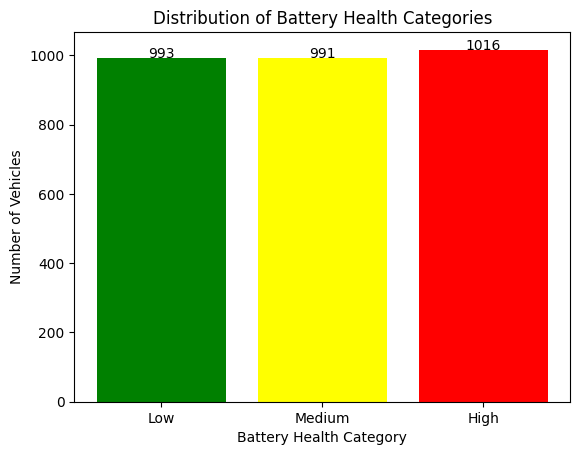

In [ ]:

class_counts = df["Battery_Class"].value_counts()

class_counts = class_counts.reindex(["Low", "Medium", "High"])

colors = ["green", "yellow", "red"]

plt.figure()
plt.bar(class_counts.index, class_counts.values, color=colors)

plt.xlabel("Battery Health Category")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Battery Health Categories")

for i, v in enumerate(class_counts.values):
    plt.text(i, v + 1, str(v), ha='center')

plt.show()

Accuracy: 0.32166666666666666
Precision: 0.3256399594010885
Recall: 0.32166666666666666
F1 Score: 0.3218539958407606


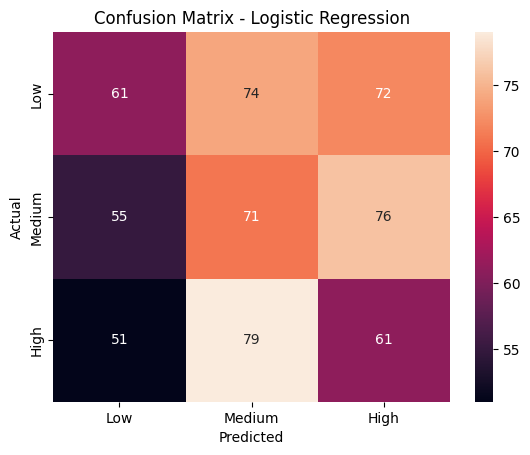

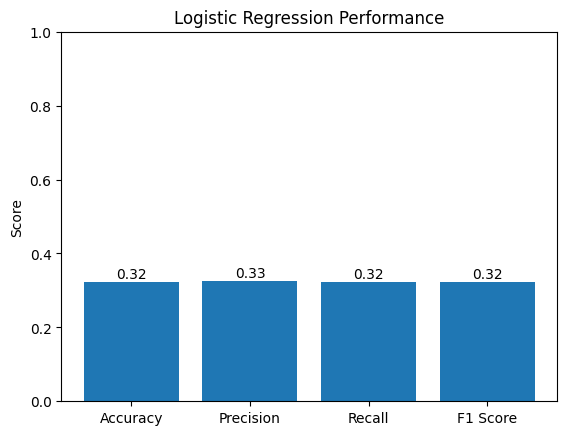

In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1]
})

results_df
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [accuracy, precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Logistic Regression Performance")
plt.ylabel("Score")
plt.ylim(0,1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

In [ ]:
df.shape
df.isnull().sum()
df.duplicated().sum()
df["Battery_Class"].value_counts()

,count
Battery_Class,
High,1016
Low,993
Medium,991


In [ ]:
X.columns

Index(['Year', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Power_kW',
       'Charging_Time_hr', 'Charge_Cycles', 'Energy_Consumption_kWh_per_100km',
       'Mileage_km', 'Avg_Speed_kmh', 'Temperature_C'],
      dtype='object')

Accuracy: 0.325
Precision: 0.32499874297545106
Recall: 0.325
F1 Score: 0.3236763209831329


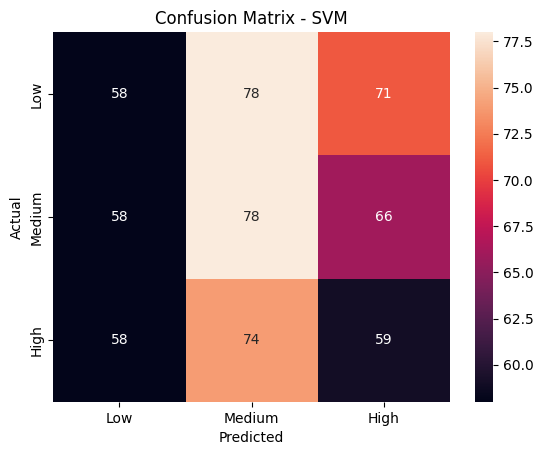

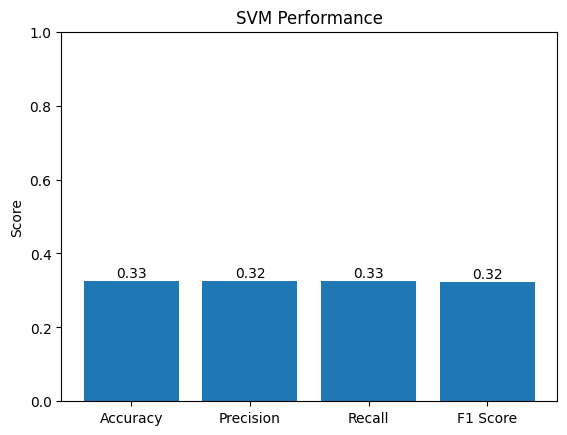

In [ ]:
from sklearn.svm import SVC

model_svm = SVC()
model_svm.fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=True, fmt='d',
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()
results_df.loc[len(results_df)] = [
    "SVM",
    accuracy_svm,
    precision_svm,
    recall_svm,
    f1_svm
]

results_df
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [accuracy_svm, precision_svm, recall_svm, f1_svm]

plt.figure()
plt.bar(metrics, values)
plt.title("SVM Performance")
plt.ylabel("Score")
plt.ylim(0,1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

Accuracy: 0.34833333333333333
Precision: 0.35083481356137763
Recall: 0.34833333333333333
F1 Score: 0.34496291477244995


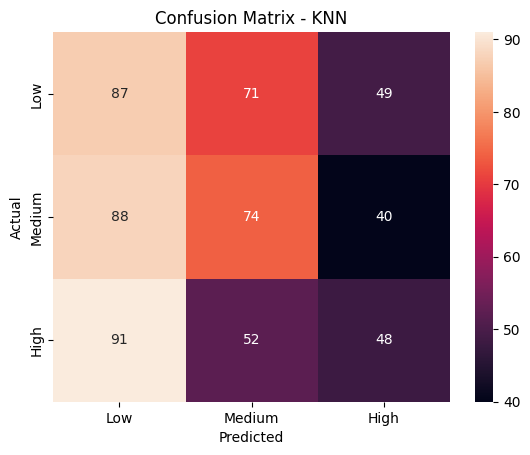

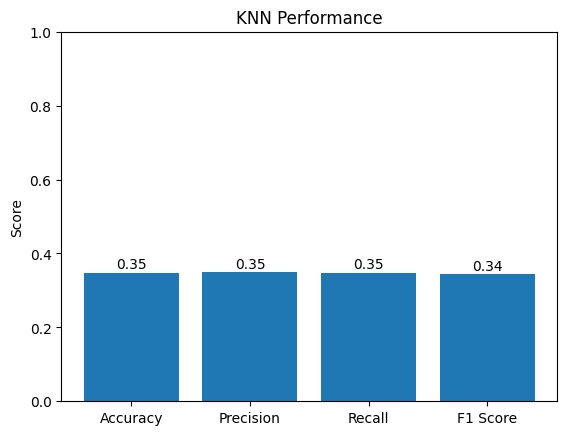

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted')
recall_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

print("Accuracy:", accuracy_knn)
print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1 Score:", f1_knn)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d',
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")
plt.show()
results_df.loc[len(results_df)] = [
    "KNN",
    accuracy_knn,
    precision_knn,
    recall_knn,
    f1_knn
]

results_df
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [accuracy_knn, precision_knn, recall_knn, f1_knn]

plt.figure()
plt.bar(metrics, values)
plt.title("KNN Performance")
plt.ylabel("Score")
plt.ylim(0,1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

Accuracy: 0.35
Precision: 0.35084053266953014
Recall: 0.35
F1 Score: 0.35035643365484587


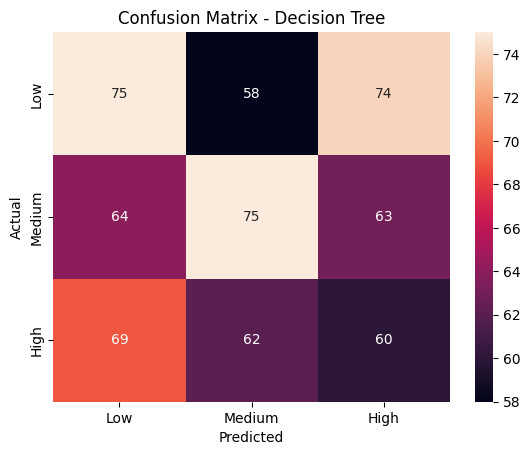

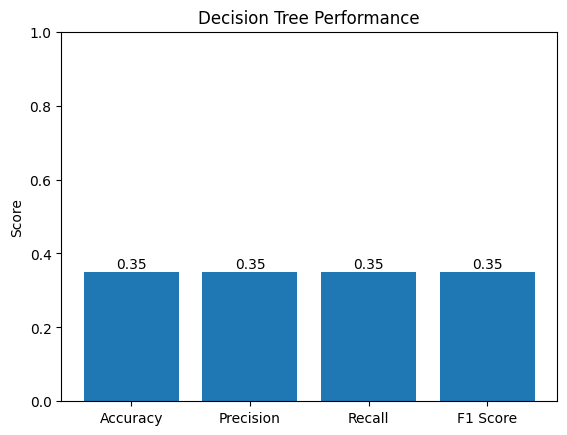

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d',
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()
results_df.loc[len(results_df)] = [
    "Decision Tree",
    accuracy_dt,
    precision_dt,
    recall_dt,
    f1_dt
]

results_df
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [accuracy_dt, precision_dt, recall_dt, f1_dt]

plt.figure()
plt.bar(metrics, values)
plt.title("Decision Tree Performance")
plt.ylabel("Score")
plt.ylim(0,1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.3233333333333333
